In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
data = pd.read_csv("house.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<Axes: ylabel='LotArea'>

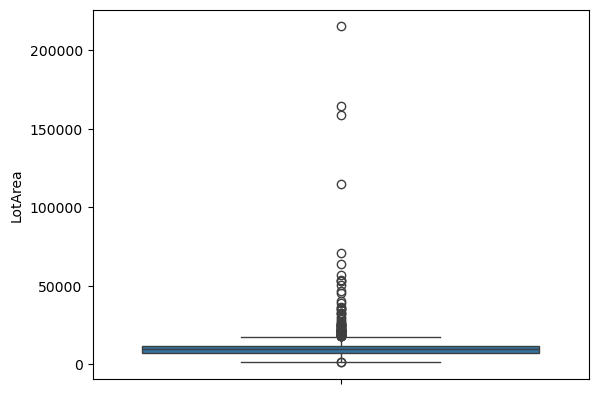

In [25]:
sns.boxplot(data['LotArea'])

In [26]:
q1 = data['LotArea'].quantile(0.25)
q1

7553.5

In [27]:
q3 = data['LotArea'].quantile(0.75)
q3

11601.5

In [28]:
iqr = q3-q1
iqr

4048.0

In [29]:
lower = q1 - (1.5 * iqr)
lower

1481.5

In [30]:
upper = q3+(1.5 * iqr)
upper

17673.5

In [9]:
new_data = data[(data['LotArea']<upper) & (data['LotArea']>lower)]

<Axes: ylabel='LotArea'>

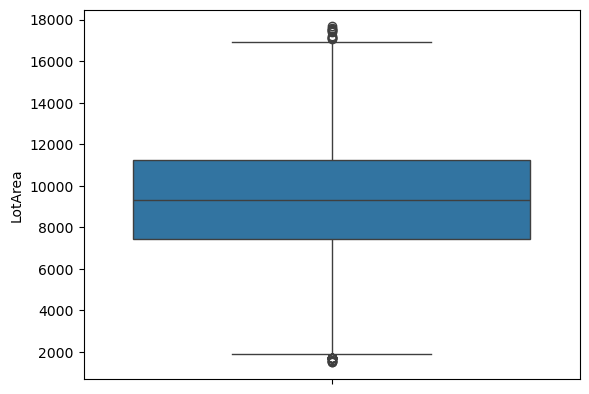

In [10]:
sns.boxplot(data=new_data,y='LotArea')

# using loop

In [12]:
num_col = data.select_dtypes("number").columns
num_col

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

BoxPlot of Id


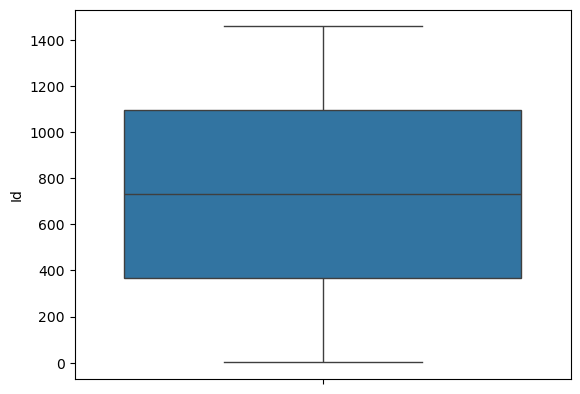

BoxPlot of MSSubClass


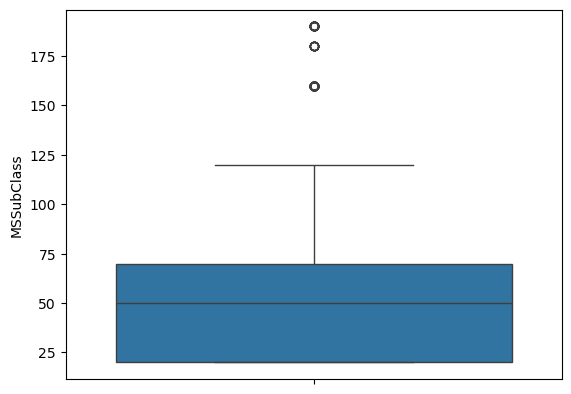

BoxPlot of LotFrontage


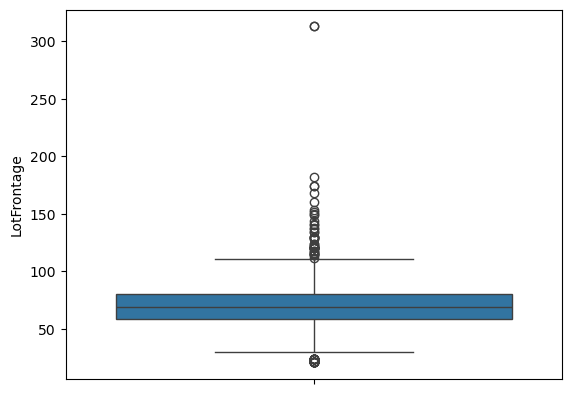

BoxPlot of LotArea


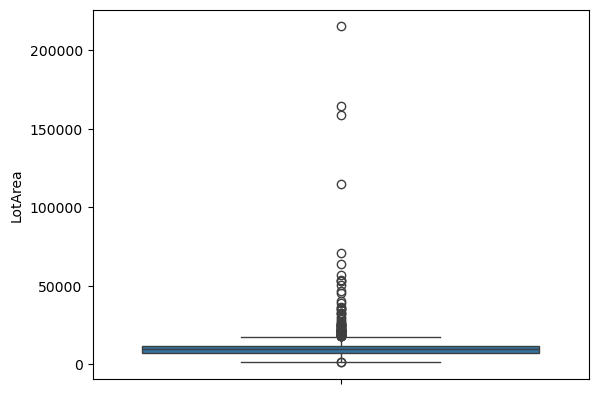

BoxPlot of OverallQual


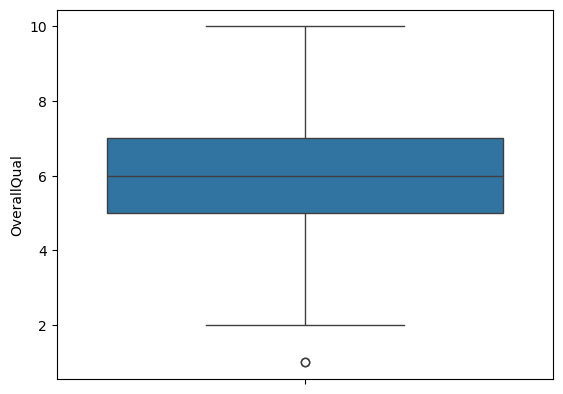

BoxPlot of OverallCond


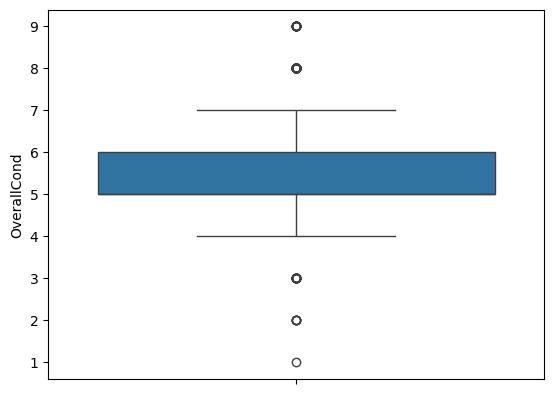

BoxPlot of YearBuilt


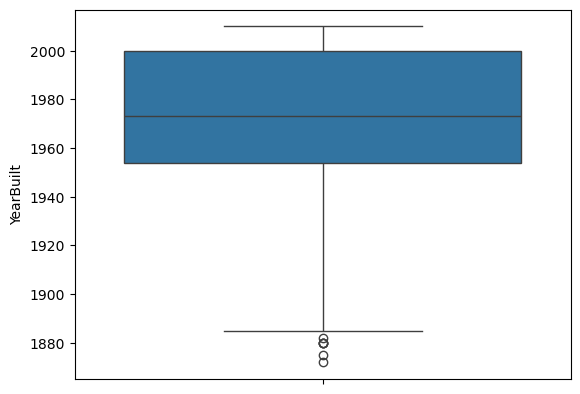

BoxPlot of YearRemodAdd


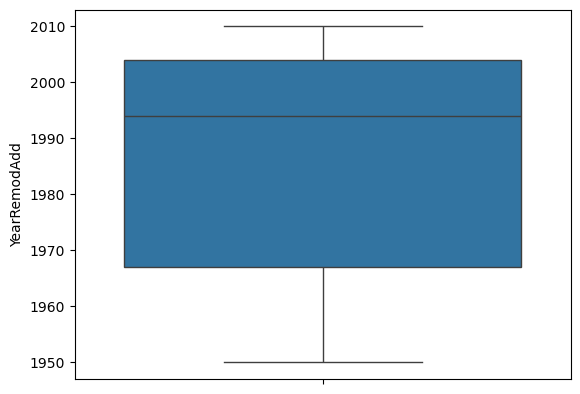

BoxPlot of MasVnrArea


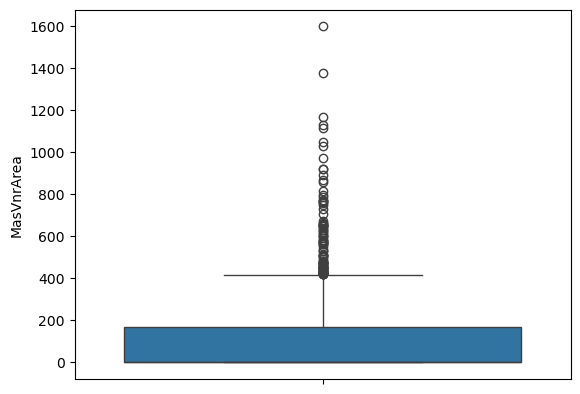

BoxPlot of BsmtFinSF1


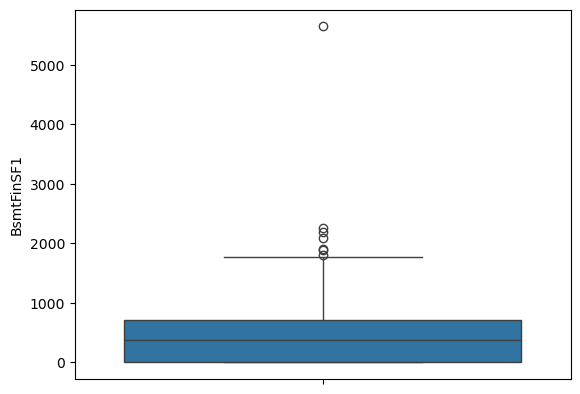

BoxPlot of BsmtFinSF2


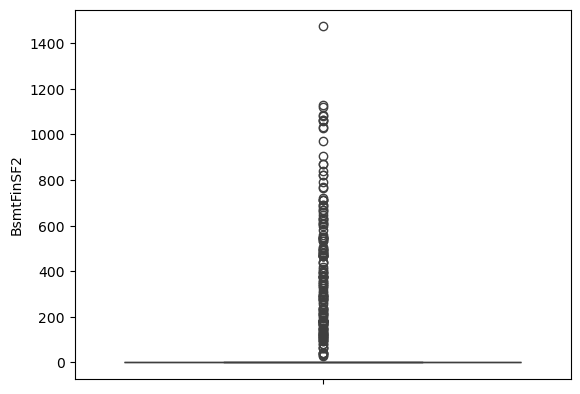

BoxPlot of BsmtUnfSF


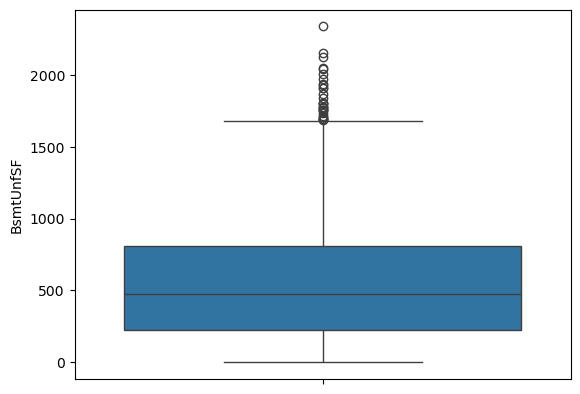

BoxPlot of TotalBsmtSF


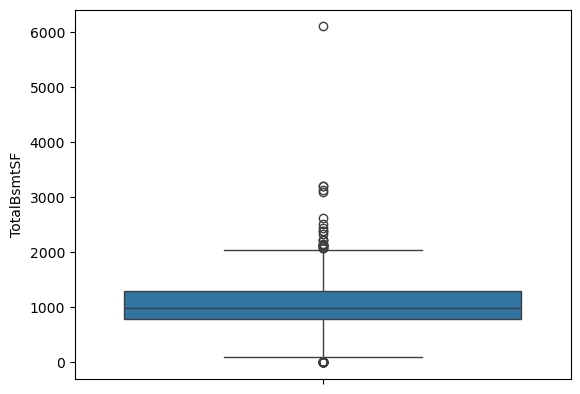

BoxPlot of 1stFlrSF


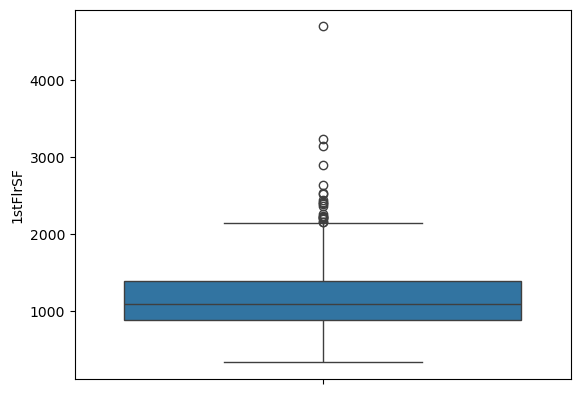

BoxPlot of 2ndFlrSF


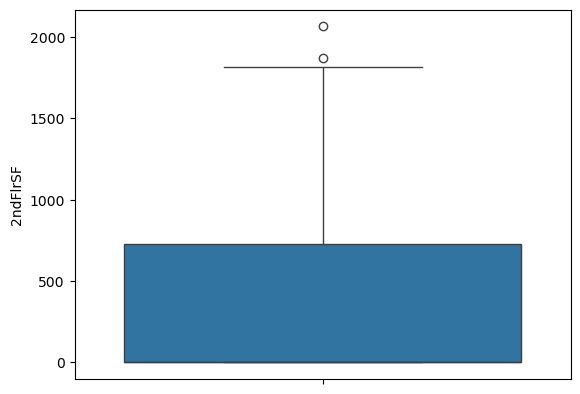

BoxPlot of LowQualFinSF


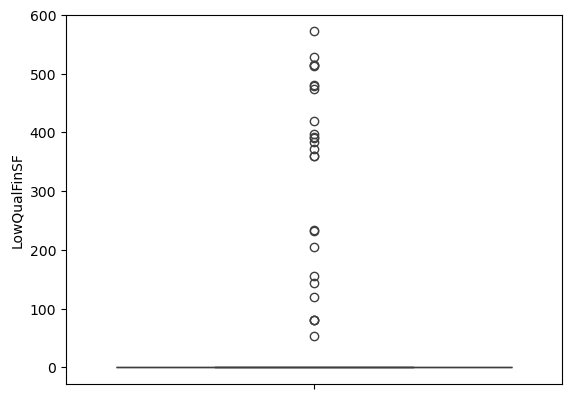

BoxPlot of GrLivArea


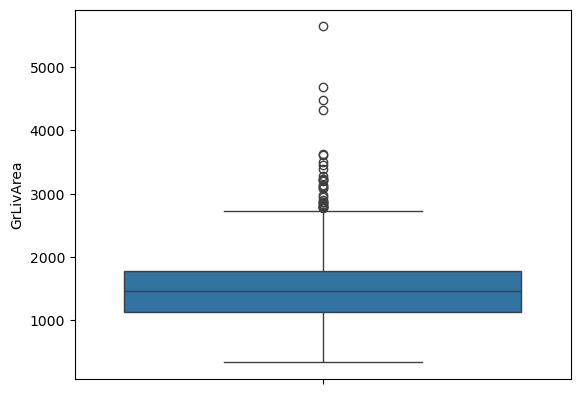

BoxPlot of BsmtFullBath


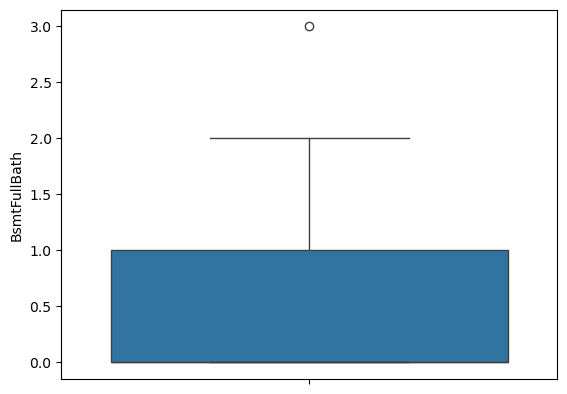

BoxPlot of BsmtHalfBath


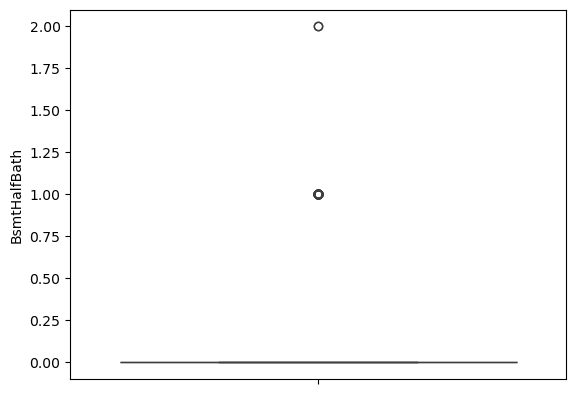

BoxPlot of FullBath


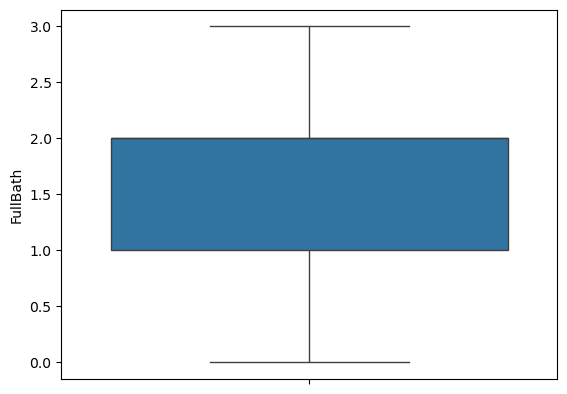

BoxPlot of HalfBath


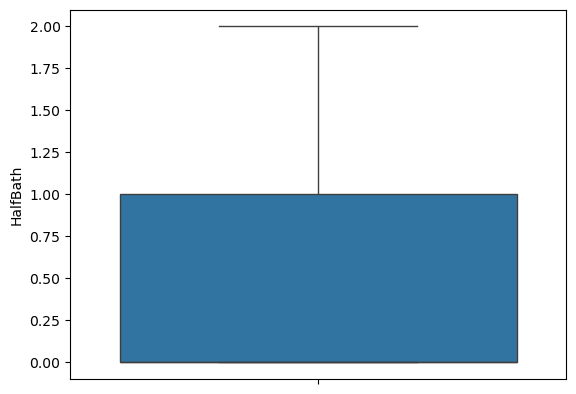

BoxPlot of BedroomAbvGr


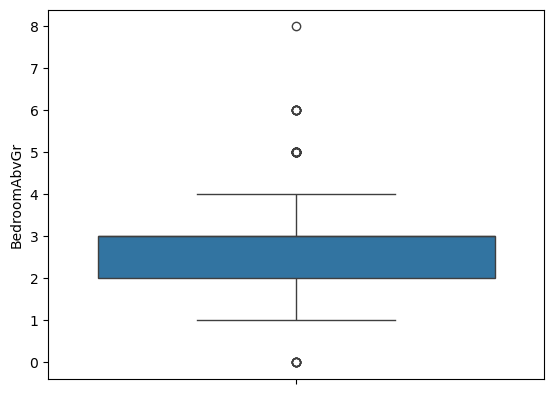

BoxPlot of KitchenAbvGr


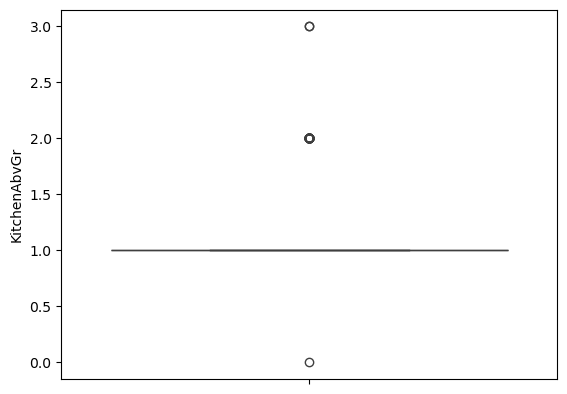

BoxPlot of TotRmsAbvGrd


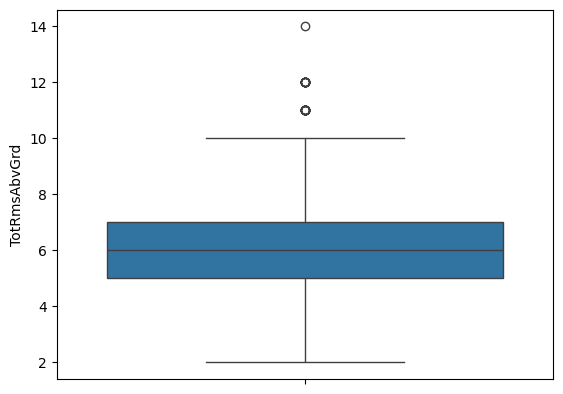

BoxPlot of Fireplaces


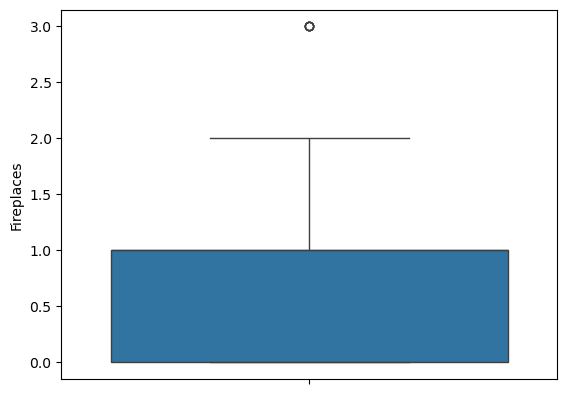

BoxPlot of GarageYrBlt


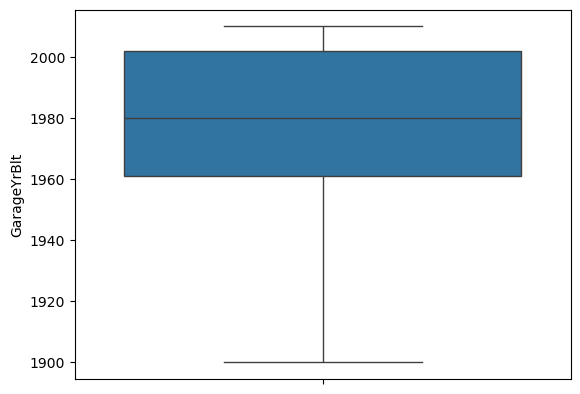

BoxPlot of GarageCars


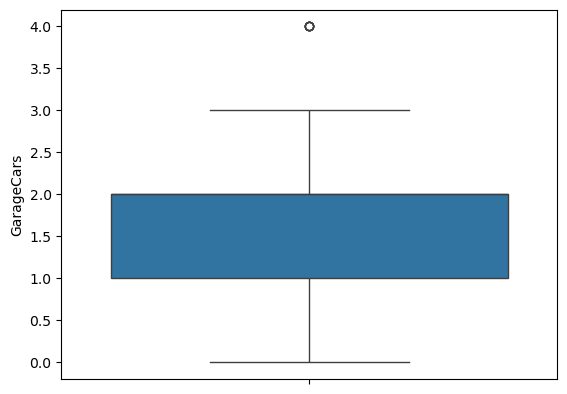

BoxPlot of GarageArea


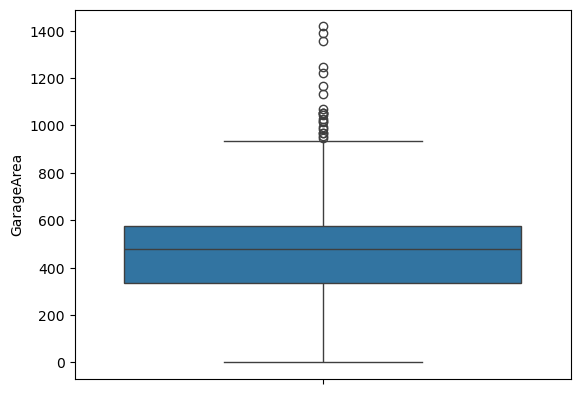

BoxPlot of WoodDeckSF


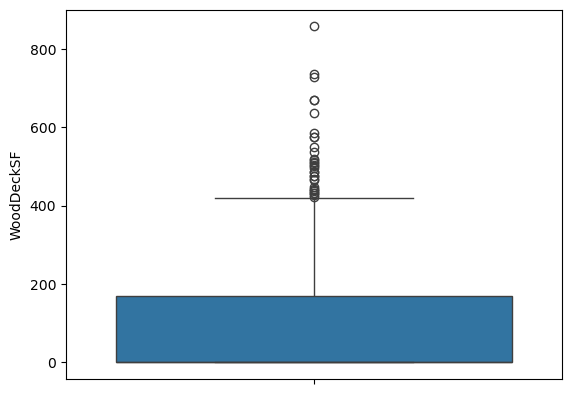

BoxPlot of OpenPorchSF


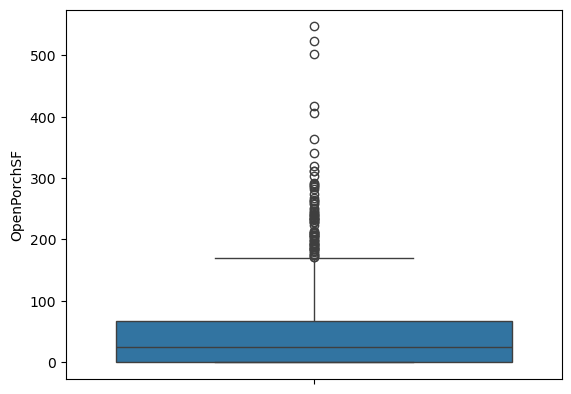

BoxPlot of EnclosedPorch


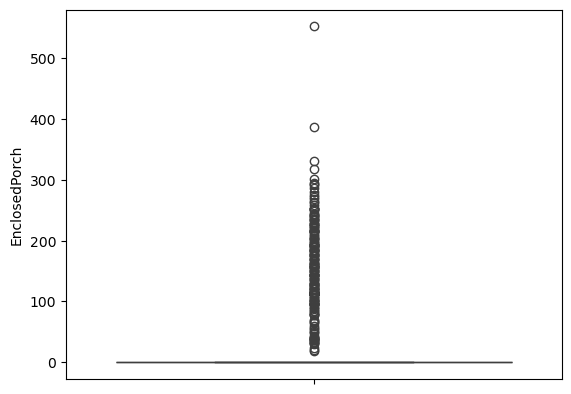

BoxPlot of 3SsnPorch


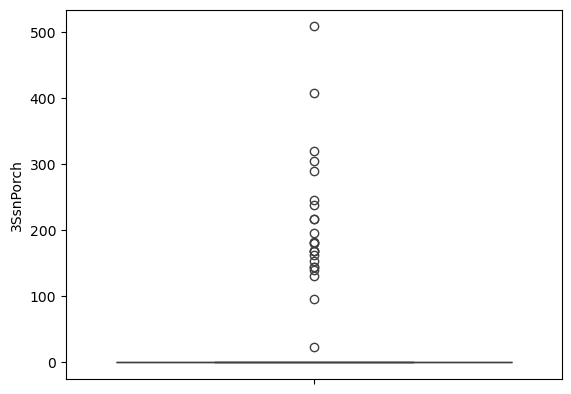

BoxPlot of ScreenPorch


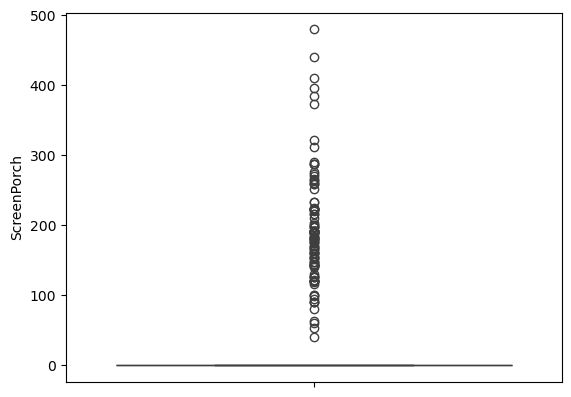

BoxPlot of PoolArea


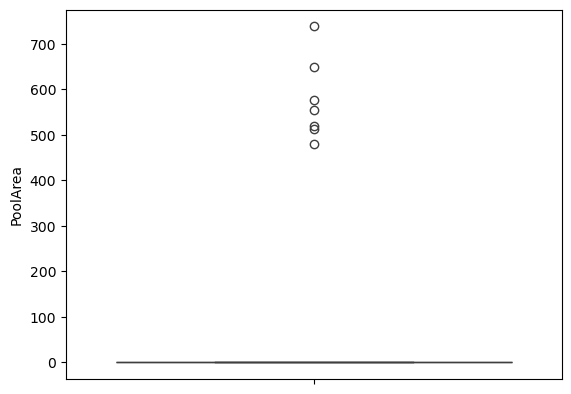

BoxPlot of MiscVal


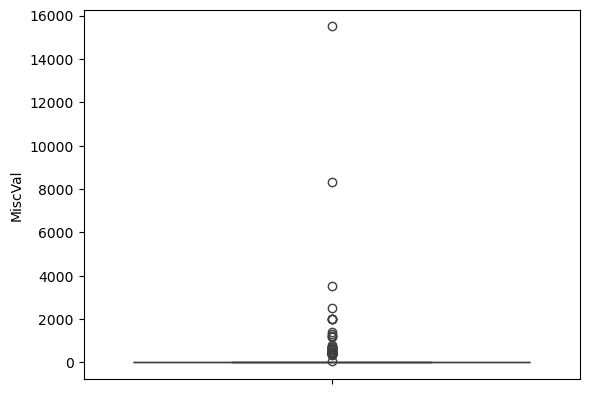

BoxPlot of MoSold


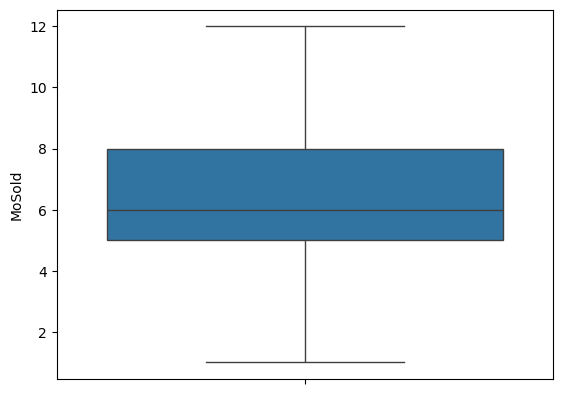

BoxPlot of YrSold


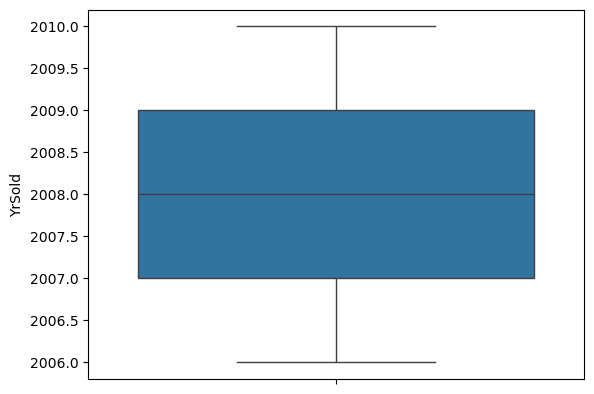

BoxPlot of SalePrice


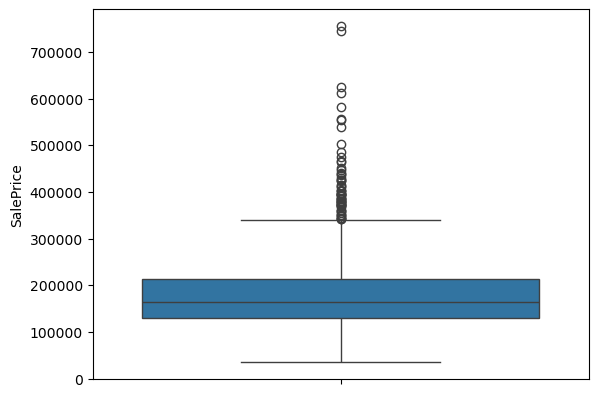

In [18]:
for i in num_col:
    print(f"BoxPlot of {i}")
    sns.boxplot(data[i])
    plt.show()

LotFrontage
59.0    69.0    10.0    44.0    84.0


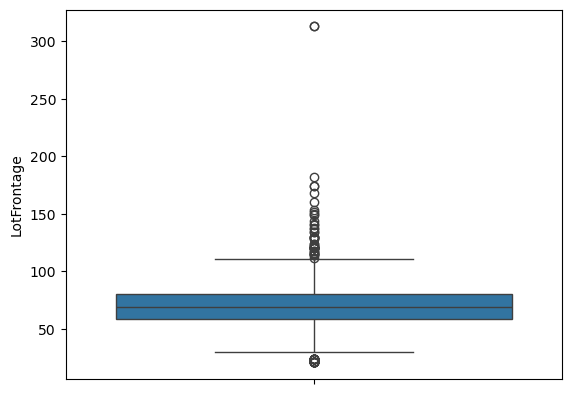

LotArea
7553.5    9478.5    1925.0    4666.0    12366.0


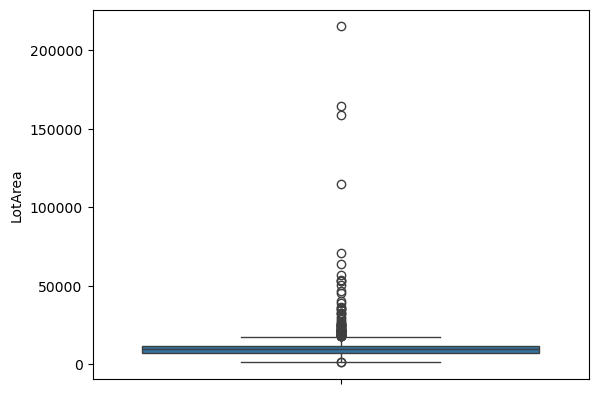

OverallQual
5.0    6.0    1.0    3.5    7.5


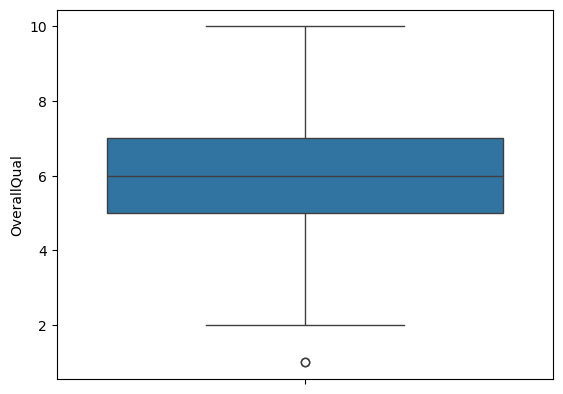

OverallCond
5.0    5.0    0.0    5.0    5.0


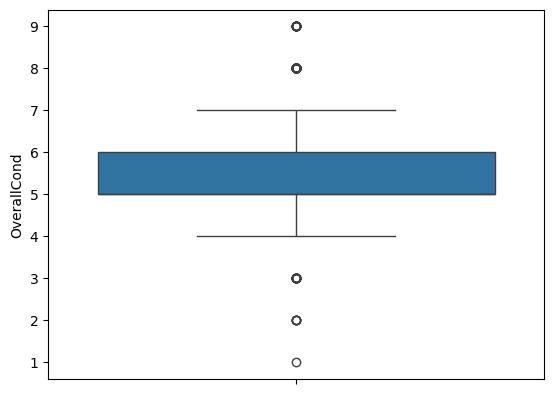

YearBuilt
1954.0    1973.0    19.0    1925.5    2001.5


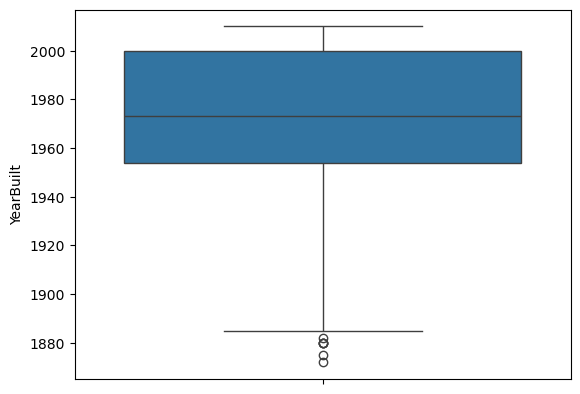

TotalBsmtSF
795.75    991.5    195.75    502.125    1285.125


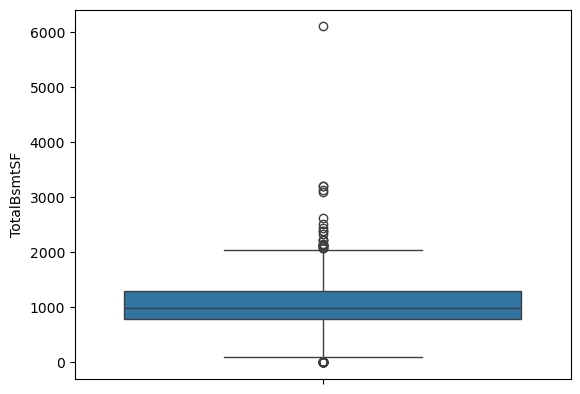

1stFlrSF
882.0    1087.0    205.0    574.5    1394.5


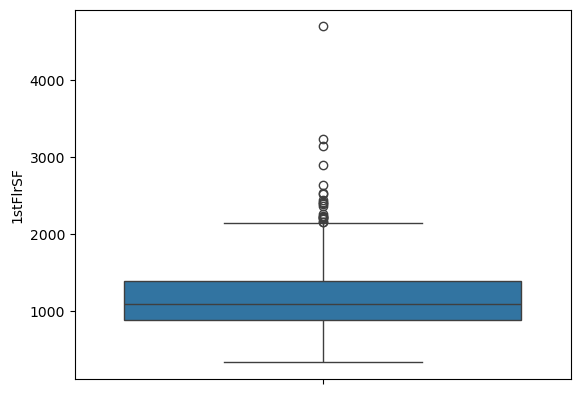

GrLivArea
1129.5    1464.0    334.5    627.75    1965.75


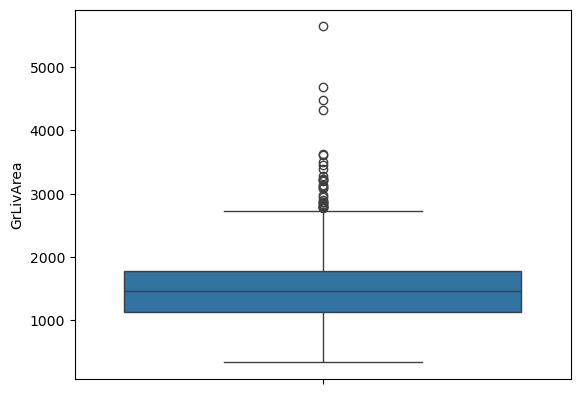

BedroomAbvGr
2.0    3.0    1.0    0.5    4.5


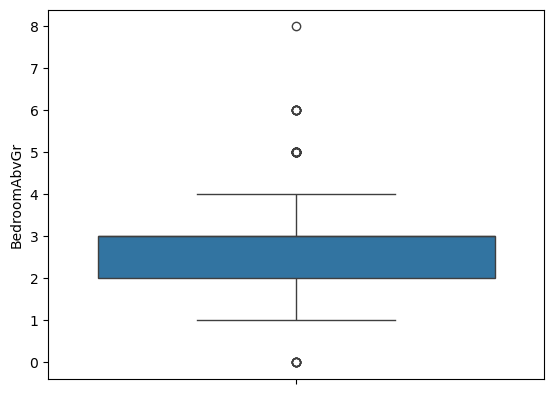

KitchenAbvGr
1.0    1.0    0.0    1.0    1.0


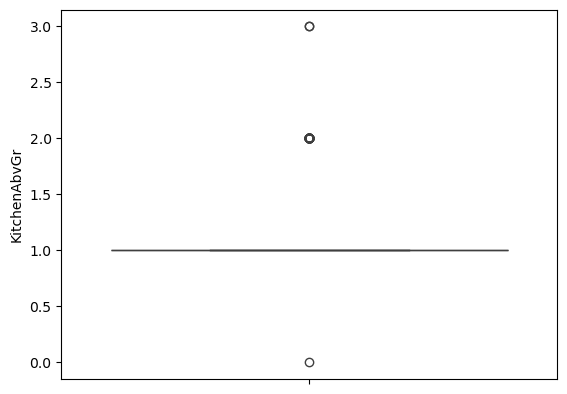

TotRmsAbvGrd
5.0    6.0    1.0    3.5    7.5


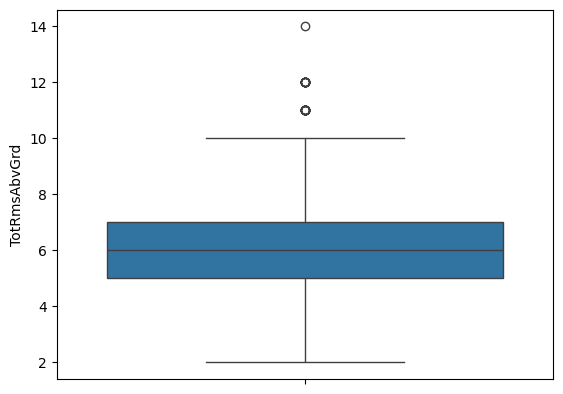

GarageYrBlt
1961.0    1980.0    19.0    1932.5    2008.5


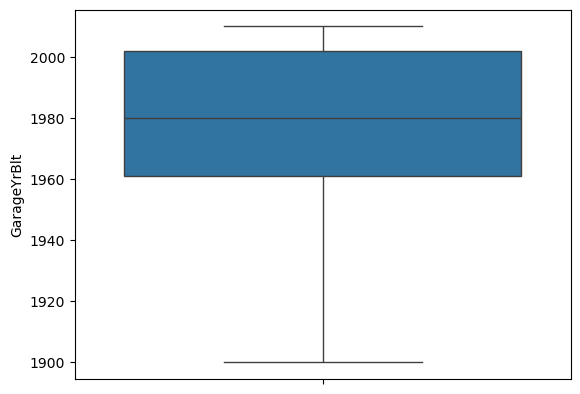

GarageArea
334.5    480.0    145.5    116.25    698.25


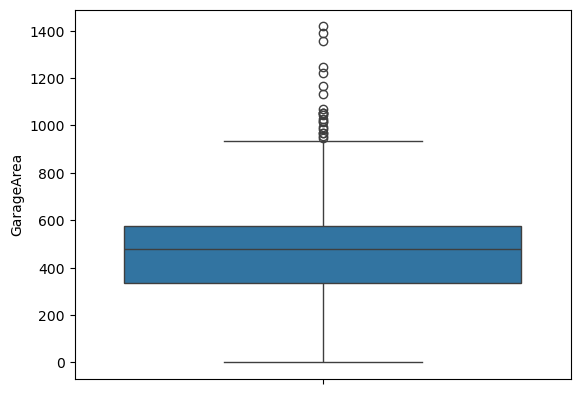

MoSold
5.0    6.0    1.0    3.5    7.5


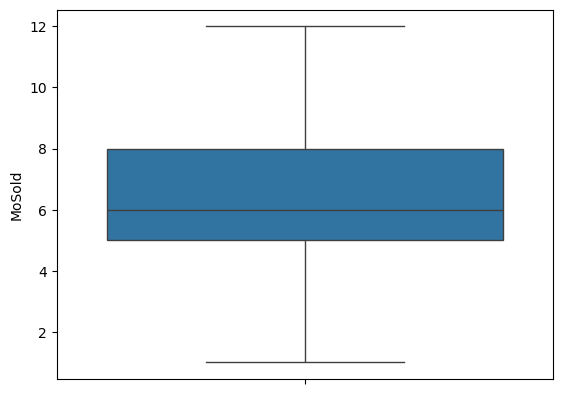

SalePrice
129975.0    163000.0    33025.0    80437.5    212537.5


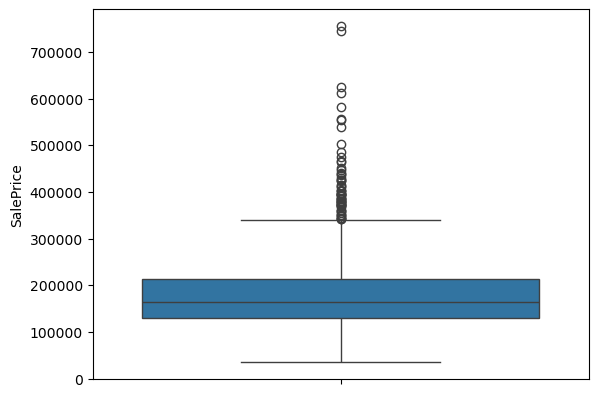

In [54]:
new_num = []
for i in num_col:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.50)
    iqr = Q3-Q1
    lower = Q1-(1.5*iqr)
    upper = Q3+(1.5*iqr)
    l = data[i][data[i]<lower]
    m = data[i][data[i]>upper]
    if (len(l) > 0) & (len(m) > 0):
        print(i)
        print(f"{Q1}    {Q3}    {iqr}    {lower}    {upper}")
        sns.boxplot(data[i])
        plt.show()
        new_num.append(i)

In [ ]:
# outliers availabel in this columns
outer = data[new_num]
outer.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,GrLivArea,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,GarageYrBlt,GarageArea,MoSold,SalePrice
0,65.0,8450,7,5,2003,856,856,1710,3,1,8,2003.0,548,2,208500
1,80.0,9600,6,8,1976,1262,1262,1262,3,1,6,1976.0,460,5,181500
2,68.0,11250,7,5,2001,920,920,1786,3,1,6,2001.0,608,9,223500
3,60.0,9550,7,5,1915,756,961,1717,3,1,7,1998.0,642,2,140000
4,84.0,14260,8,5,2000,1145,1145,2198,4,1,9,2000.0,836,12,250000


LotFrontage
59.0    69.0    10.0    44.0    84.0


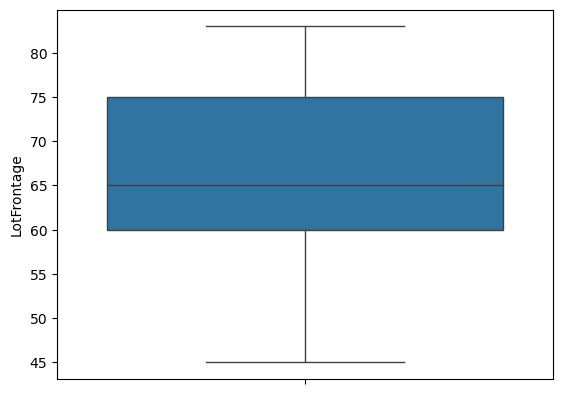

LotArea
7553.5    9478.5    1925.0    4666.0    12366.0


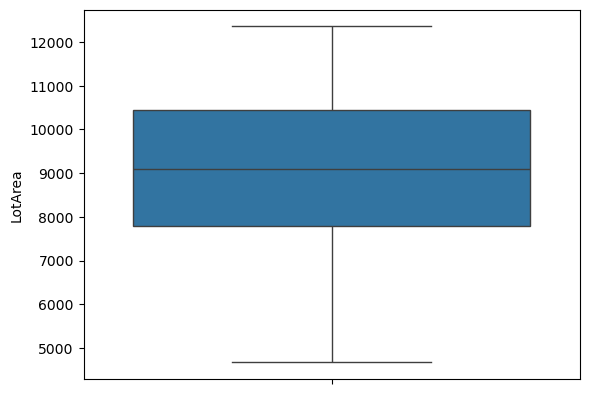

OverallQual
5.0    6.0    1.0    3.5    7.5


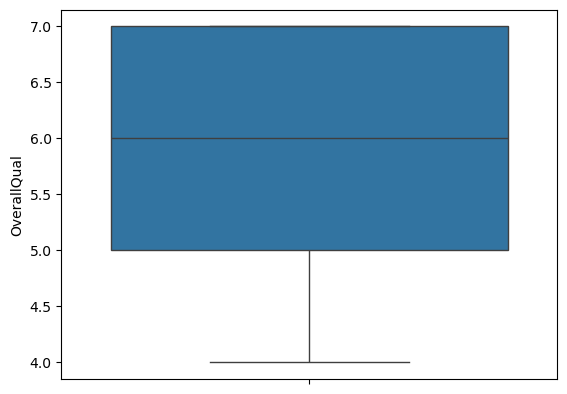

OverallCond
5.0    5.0    0.0    5.0    5.0


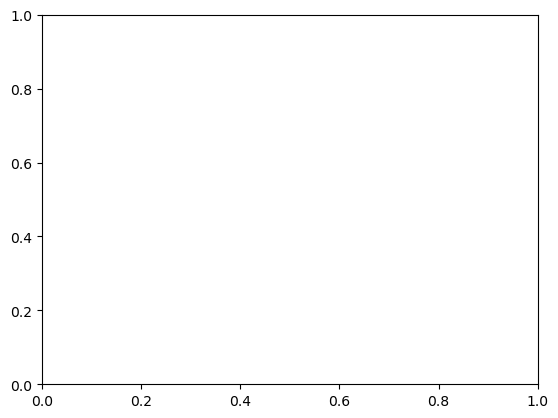

YearBuilt
1954.0    1973.0    19.0    1925.5    2001.5


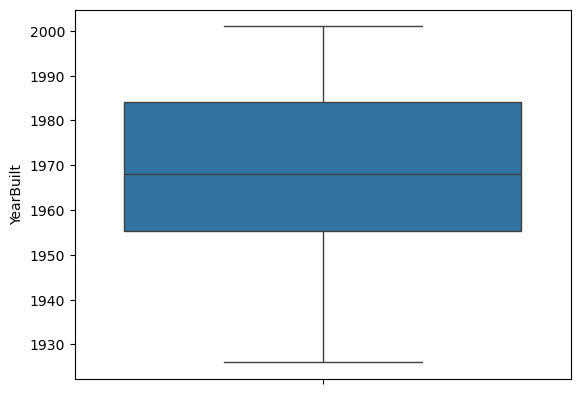

TotalBsmtSF
795.75    991.5    195.75    502.125    1285.125


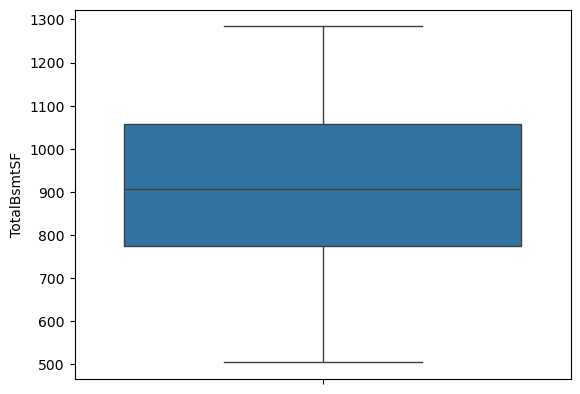

1stFlrSF
882.0    1087.0    205.0    574.5    1394.5


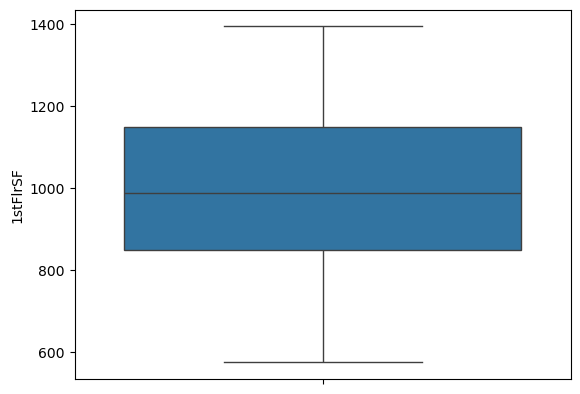

GrLivArea
1129.5    1464.0    334.5    627.75    1965.75


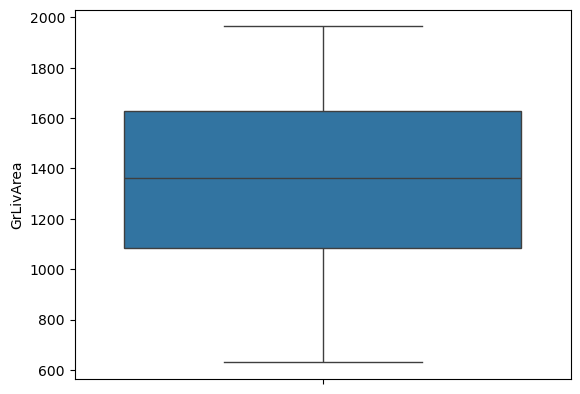

BedroomAbvGr
2.0    3.0    1.0    0.5    4.5


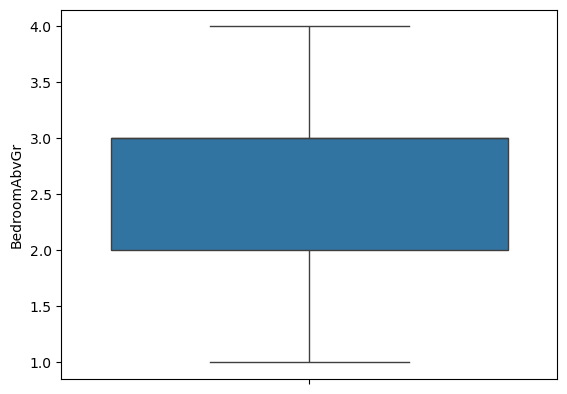

KitchenAbvGr
1.0    1.0    0.0    1.0    1.0


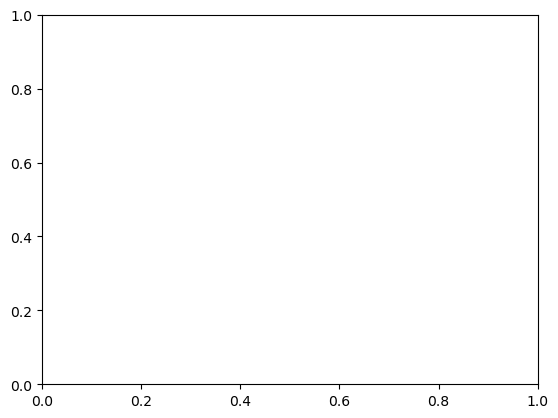

TotRmsAbvGrd
5.0    6.0    1.0    3.5    7.5


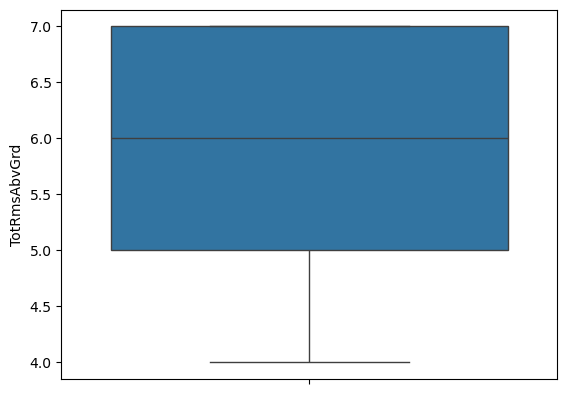

GarageYrBlt
1961.0    1980.0    19.0    1932.5    2008.5


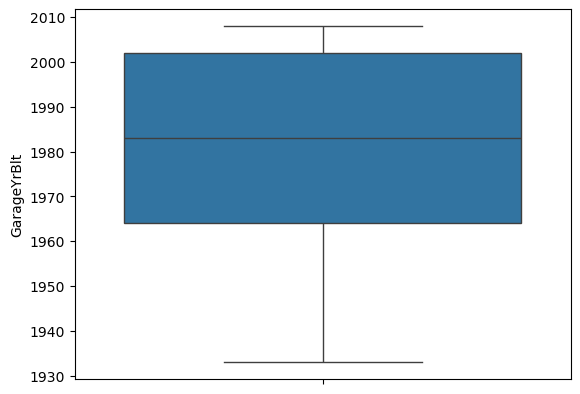

GarageArea
334.5    480.0    145.5    116.25    698.25


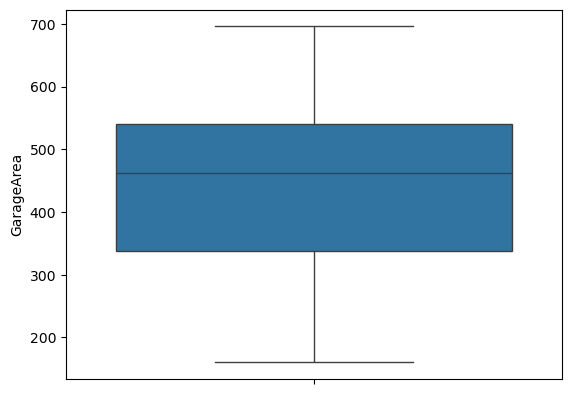

MoSold
5.0    6.0    1.0    3.5    7.5


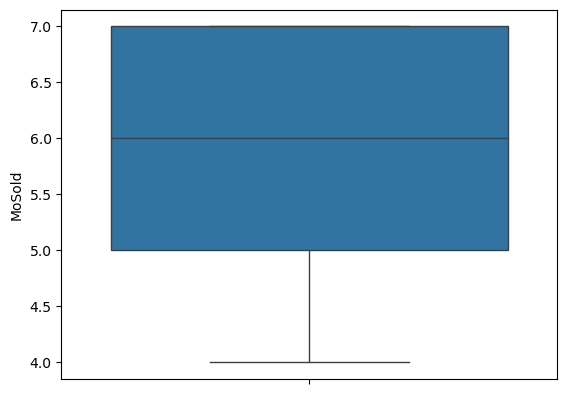

SalePrice
129975.0    163000.0    33025.0    80437.5    212537.5


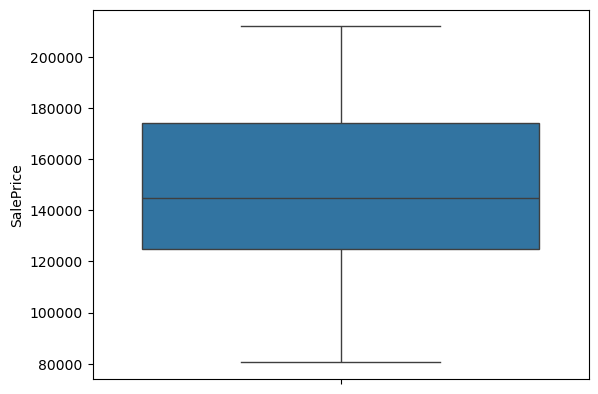

In [ ]:
# boxplot after removing outliers
for i in new_num:
    print(i)
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.50)
    iqr = Q3-Q1
    lower = Q1-(1.5*iqr)
    upper = Q3+(1.5*iqr)
    print(f"{Q1}    {Q3}    {iqr}    {lower}    {upper}")
    sns.boxplot(data[i][(data[i]>lower)&(data[i]<upper)])
    plt.show()
    

LotFrontage


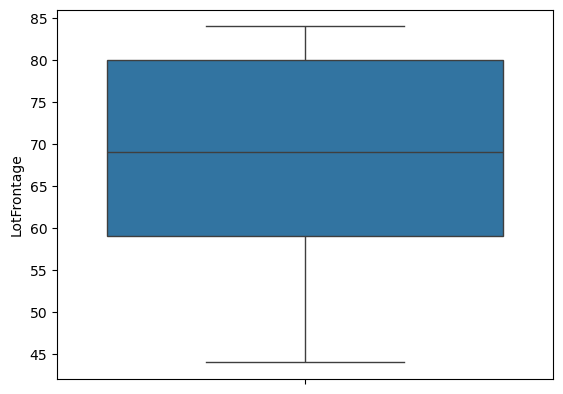

LotArea


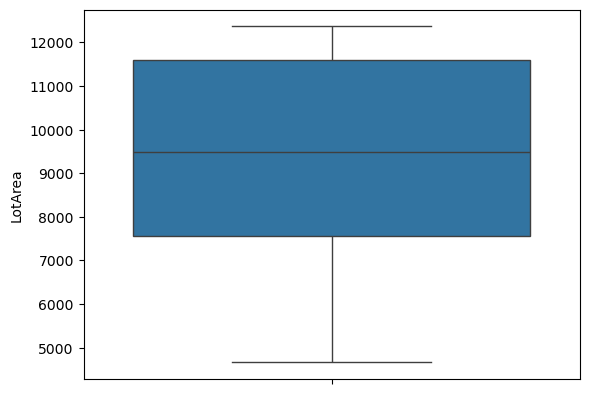

OverallQual


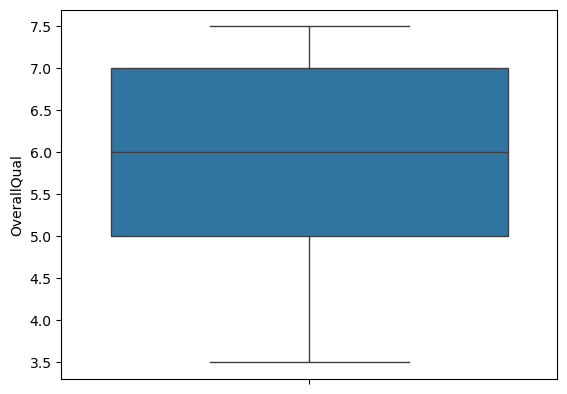

OverallCond


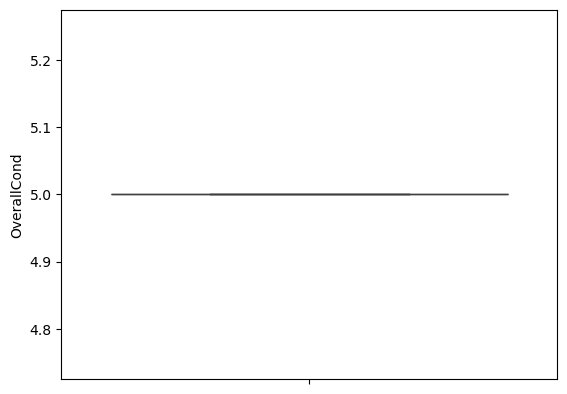

YearBuilt


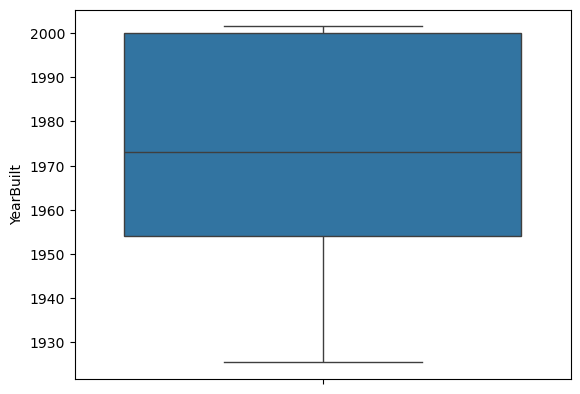

TotalBsmtSF


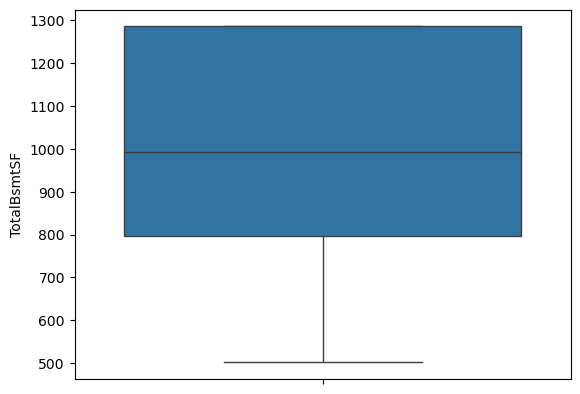

1stFlrSF


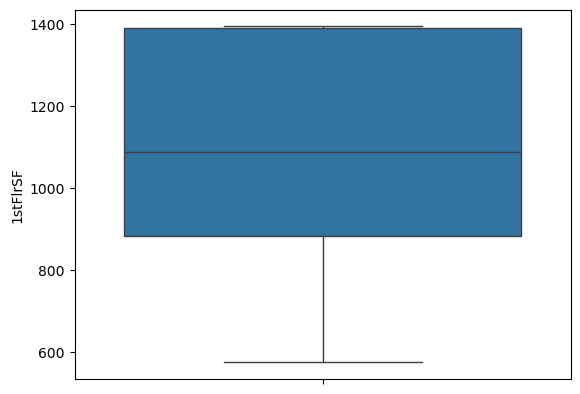

GrLivArea


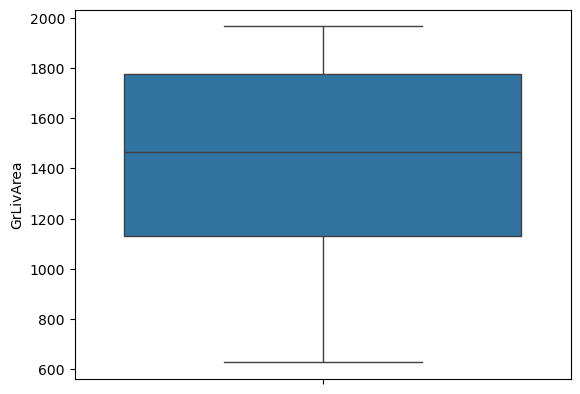

BedroomAbvGr


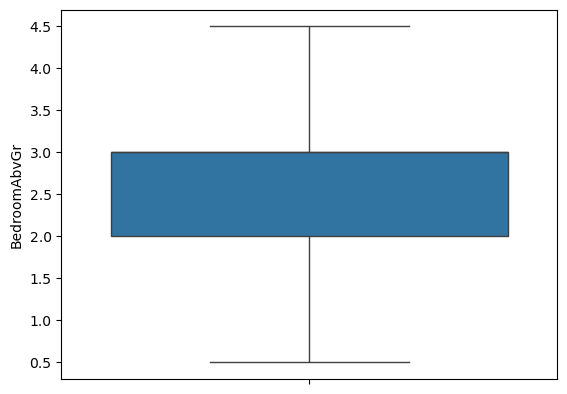

KitchenAbvGr


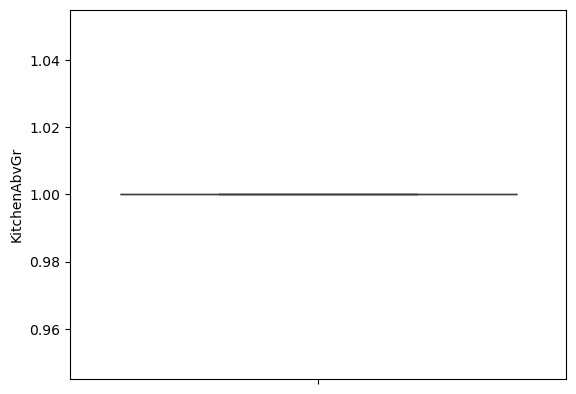

TotRmsAbvGrd


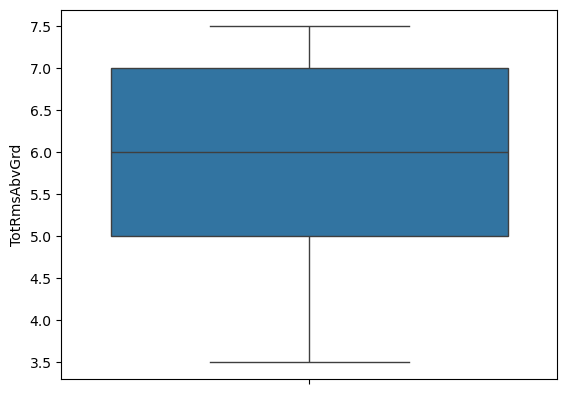

GarageYrBlt


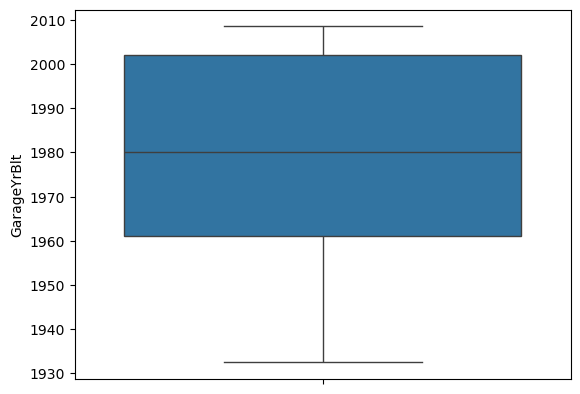

GarageArea


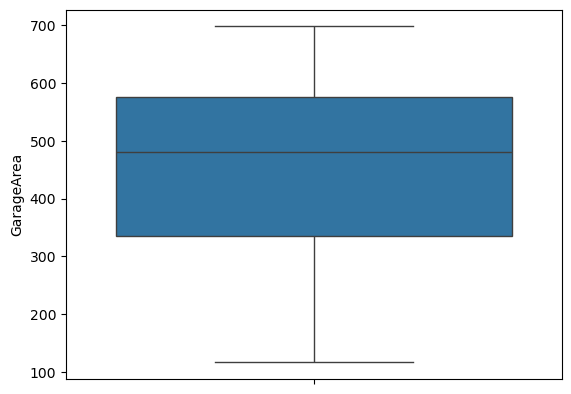

MoSold


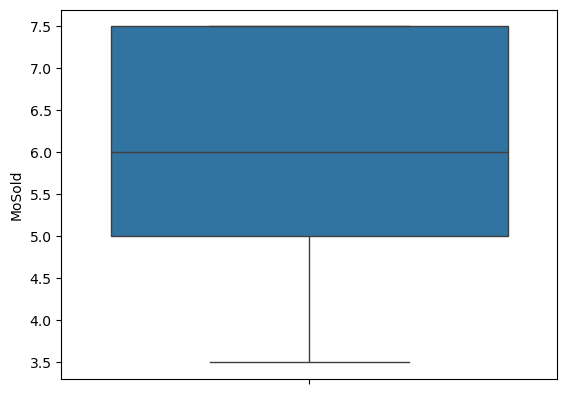

SalePrice


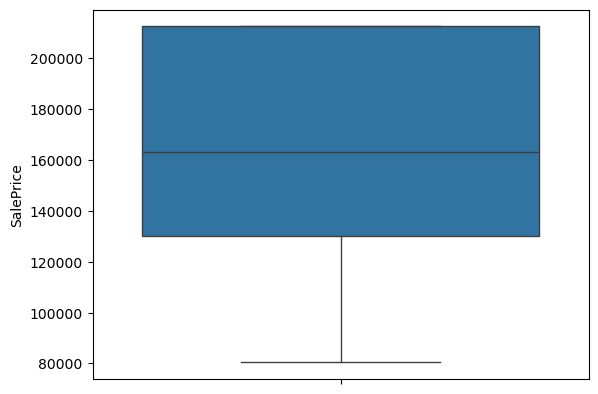

In [63]:
# capping outerliers
new_num               # availabel outlier
for i in new_num:  
    print(i)       
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.50)
    iqr = Q3-Q1
    lower = Q1-(1.5*iqr)
    upper = Q3+(1.5*iqr)
    data[i].clip(lower,upper,inplace=True)            # capping outliers
    sns.boxplot(data[i])                               # boxplot after capping outliers
    plt.show()

    